In [3]:
import pandas as pd


df = pd.read_parquet("15min_data.parquet")
df = df.rename(columns={"Date": "Datetime"})
df = df.sort_values(["Ticker", "Datetime"])
print(df.head(50))

   Ticker            Datetime      Open      High       Low     Close   Volume
0    AAPL 2019-09-16 09:30:00  54.61750  54.69500  54.39003  54.59250  9712044
1    AAPL 2019-09-16 09:45:00  54.55000  54.95612  54.54250  54.92000  6860892
2    AAPL 2019-09-16 10:00:00  54.92800  54.93250  54.71973  54.74000  4395356
3    AAPL 2019-09-16 10:15:00  54.74000  54.82248  54.58625  54.59750  3583344
4    AAPL 2019-09-16 10:30:00  54.60000  54.74500  54.54750  54.71250  3211824
5    AAPL 2019-09-16 10:45:00  54.71750  54.74750  54.60750  54.72500  2391316
6    AAPL 2019-09-16 11:00:00  54.73125  54.91500  54.72000  54.90425  3380376
7    AAPL 2019-09-16 11:15:00  54.90500  55.02375  54.83000  54.97650  4166960
8    AAPL 2019-09-16 11:30:00  54.97500  55.00750  54.91750  54.99750  3311716
9    AAPL 2019-09-16 11:45:00  54.99750  55.03250  54.72500  54.76250  3973272
10   AAPL 2019-09-16 12:00:00  54.76000  54.83475  54.74500  54.80000  1804100
11   AAPL 2019-09-16 12:15:00  54.79750  54.85000  5

In [4]:
df = df.copy()

cols = ["Open", "High", "Low", "Close", "Volume"]

for col in cols:
    df[f"{col}_perc"] = (
        df.groupby("Ticker")[col]
        .pct_change() * 100
    )

df.head(50)

,Ticker,Datetime,Open,High,Low,Close,Volume,Open_perc,High_perc,Low_perc,Close_perc,Volume_perc
0,AAPL,2019-09-16 09:30:00,54.61750,54.69500,54.39003,54.59250,9712044,NaN,NaN,NaN,NaN,NaN
1,AAPL,2019-09-16 09:45:00,54.55000,54.95612,54.54250,54.92000,6860892,-0.123587,0.477411,0.280327,0.599899,-29.356869
2,AAPL,2019-09-16 10:00:00,54.92800,54.93250,54.71973,54.74000,4395356,0.692942,-0.042980,0.324939,-0.327749,-35.936085
3,AAPL,2019-09-16 10:15:00,54.74000,54.82248,54.58625,54.59750,3583344,-0.342266,-0.200282,-0.243934,-0.260322,-18.474317
4,AAPL,2019-09-16 10:30:00,54.60000,54.74500,54.54750,54.71250,3211824,-0.255754,-0.141329,-0.070989,0.210632,-10.367969
5,AAPL,2019-09-16 10:45:00,54.71750,54.74750,54.60750,54.72500,2391316,0.215201,0.004567,0.109996,0.022847,-25.546481
6,AAPL,2019-09-16 11:00:00,54.73125,54.91500,54.72000,54.90425,3380376,0.025129,0.305950,0.206016,0.327547,41.360489
7,AAPL,2019-09-16 11:15:00,54.90500,55.02375,54.83000,54.97650,4166960,0.317460,0.198033,0.201023,0.131593,23.269127
8,AAPL,2019-09-16 11:30:00,54.97500,55.00750,54.91750,54.99750,3311716,0.127493,-0.029533,0.159584,0.038198,-20.524411
9,AAPL,2019-09-16 11:45:00,54.99750,55.03250,54.72500,54.76250,3973272,0.040928,0.045448,-0.350526,-0.427292,19.976230


# Метрики

In [5]:
import numpy as np
from typing import Union

SeriesLike = Union[pd.Series, np.ndarray, list]


def _to_arrays(y_true: SeriesLike, y_pred: SeriesLike):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    df = pd.concat([y_true, y_pred], axis=1).dropna()
    return df.iloc[:, 0].to_numpy(), df.iloc[:, 1].to_numpy()


# Абосютные ошибки:
def mae(y_true: SeriesLike, y_pred: SeriesLike):
    y_true, y_pred = _to_arrays(y_true, y_pred)
    return np.mean(np.abs(y_true - y_pred))


def mse(y_true: SeriesLike, y_pred: SeriesLike):
    y_true, y_pred = _to_arrays(y_true, y_pred)
    return np.mean((y_true - y_pred) ** 2)


def rmse(y_true: SeriesLike, y_pred: SeriesLike):
    return np.sqrt(mse(y_true, y_pred))


def mdae(y_true: SeriesLike, y_pred: SeriesLike):
    y_true, y_pred = _to_arrays(y_true, y_pred)
    return np.median(np.abs(y_true - y_pred))


def mdse(y_true: SeriesLike, y_pred: SeriesLike):
    y_true, y_pred = _to_arrays(y_true, y_pred)
    return np.median((y_true - y_pred) ** 2)


# Относительные ошибки
def mape(y_true: SeriesLike, y_pred: SeriesLike):
    y_true, y_pred = _to_arrays(y_true, y_pred)
    if np.any(y_true == 0):
        raise ValueError("MAPE неопределён, y_true содержит нули")
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def smape(y_true: SeriesLike, y_pred: SeriesLike):
    y_true, y_pred = _to_arrays(y_true, y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred))
    zero_mask = denom == 0
    denom[zero_mask] = np.nan
    return np.nanmean(np.abs(y_true - y_pred) / denom) * 200


def mspe(y_true: SeriesLike, y_pred: SeriesLike):
    y_true, y_pred = _to_arrays(y_true, y_pred)
    if np.any(y_true == 0):
        raise ValueError("MSPE неопределён, y_true содержит нули")
    return np.mean(((y_true - y_pred) / y_true) ** 2)


def rmspe(y_true: SeriesLike, y_pred: SeriesLike):
    return np.sqrt(mspe(y_true, y_pred))


# Взвешенные ошибки
def wape(y_true: SeriesLike, y_pred: SeriesLike):
    y_true, y_pred = _to_arrays(y_true, y_pred)
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))


# Масштабированные метрики

def mase(y_true: SeriesLike, y_pred: SeriesLike, seasonality: int = 1):
    """
    Mean Absolute Scaled Error from Hyndman.
    seasonality = 1 → naive differences (no seasonality)
    seasonality = m → seasonal naive benchmark
    """
    y_true, y_pred = _to_arrays(y_true, y_pred)
    y = pd.Series(y_true)

    if len(y) <= seasonality:
        raise ValueError("Ряд слишком короткий для заданной seasonality")

    scale = np.mean(np.abs(y[seasonality:].to_numpy() - y[:-seasonality].to_numpy()))
    if scale == 0:
        raise ValueError("Scaling factor равен 0; MASE неопределён")

    return np.mean(np.abs(y_true - y_pred)) / scale


def rmsse(y_true: SeriesLike, y_pred: SeriesLike, seasonality: int = 1):
    y_true, y_pred = _to_arrays(y_true, y_pred)
    y = pd.Series(y_true)

    if len(y) <= seasonality:
        raise ValueError("Ряд слишком короткий для заданной RMSSE seasonality")

    scale = np.mean((y[seasonality:].to_numpy() - y[:-seasonality].to_numpy()) ** 2)
    if scale == 0:
        raise ValueError("Scaling factor равен 0; MASE неопределён")

    return np.sqrt(np.mean((y_true - y_pred) ** 2) / scale)


# Относительные оишбки (относительно какой-то baseline-модели)

def rae(y_true: SeriesLike, y_pred: SeriesLike, y_baseline: SeriesLike):
    """Relative Absolute Error."""
    y_true, y_pred = _to_arrays(y_true, y_pred)
    y_true_b, y_base = _to_arrays(y_true, y_baseline)
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true_b - y_base))


def rse(y_true: SeriesLike, y_pred: SeriesLike, y_baseline: SeriesLike):
    """Relative Squared Error."""
    y_true, y_pred = _to_arrays(y_true, y_pred)
    y_true_b, y_base = _to_arrays(y_true, y_baseline)
    return np.sum((y_true - y_pred) ** 2) / np.sum((y_true_b - y_base) ** 2)


def rmae(y_true: SeriesLike, y_pred: SeriesLike, y_baseline: SeriesLike):
    return rae(y_true, y_pred, y_baseline)


def rrmse(y_true: SeriesLike, y_pred: SeriesLike, y_baseline: SeriesLike):
    return np.sqrt(rse(y_true, y_pred, y_baseline))


# Нормализованные метрики

def nrmse_std(y_true: SeriesLike, y_pred: SeriesLike):
    """Normalize RMSE by standard deviation of y_true."""
    y_true, y_pred = _to_arrays(y_true, y_pred)
    return rmse(y_true, y_pred) / np.std(y_true)


def nmae_range(y_true: SeriesLike, y_pred: SeriesLike):
    """Normalize MAE by value range."""
    y_true, y_pred = _to_arrays(y_true, y_pred)
    rng = np.max(y_true) - np.min(y_true)
    if rng == 0:
        raise ValueError("Range равен 0; NMAE неопределён")
    return mae(y_true, y_pred) / rng

# Прогнозы временных рядов с помощью классических методов

In [6]:
def prepare_data(df, ticker, target_col="target", datetime_col="Datetime"):
    """
    Фильтрует данные по тикеру, сортирует по времени и создаёт числовой временной индекс.
    """
    df = df[df["Ticker"] == ticker].copy()

    # Приведение к datetime и сортировка
    df[datetime_col] = pd.to_datetime(df[datetime_col])
    df = df.sort_values(datetime_col).reset_index(drop=True)

    # Порядковый индекс времени
    df["time_idx"] = np.arange(len(df))

    return df[[datetime_col, "time_idx", target_col]].reset_index(drop=True)

amzn = prepare_data(df, 'AMZN', target_col="Close_perc")
amzn.tail()

,Datetime,time_idx,Close_perc
40070,2025-11-07 14:45:00,40070,0.174807
40071,2025-11-07 15:00:00,40071,0.065699
40072,2025-11-07 15:15:00,40072,-0.139514
40073,2025-11-07 15:30:00,40073,0.579365
40074,2025-11-07 15:45:00,40074,-0.151156


### Простые прогнозы на основе классических методов:

In [7]:
def naive_forecast(series, horizon):
    # Наивный метод y^​t+1​=yt​
    last_value = series.iloc[-1]
    return np.repeat(last_value, horizon)


def seasonal_naive_forecast(series, horizon, season_length=7):
    """
    season_length = 26 - дневная сезонность
    """
    values = series.iloc[-season_length:]
    repeats = horizon // season_length + 1
    return np.tile(values, repeats)[:horizon]


def moving_average_forecast(series, horizon, window=26, mode="shift"):
    """
    Реально рекурсивный вариант Moving Average:
    mode = "shift"     → фиксированное окно
    mode = "expanding" → растущее окно
    """

    history = list(series)
    forecasts = []

    for i in range(horizon):

        if mode == "shift":
            current_window = window

        elif mode == "expanding":
            current_window = window + i

        else:
            raise ValueError("mode должен быть 'shift' или 'expanding'.")

        # ограничиваем окно длиной истории
        current_window = min(current_window, len(history))

        # среднее по окну
        ma = np.mean(history[-current_window:])

        # записываем прогноз
        forecasts.append(ma)

        # рекурсивность: добавляем прогноз в историю
        history.append(ma)

    return np.array(forecasts)



def drift_forecast(series, horizon, lookback=None):
    """
    lookback: если None - используем всю выборку, иначе используем последние lookback точек
    """
    if lookback is not None:
        series = series.iloc[-lookback:]

    y1 = series.iloc[0]
    y_last = series.iloc[-1]
    n = len(series)

    drift = (y_last - y1) / (n - 1)
    return y_last + drift * np.arange(1, horizon + 1)


from statsmodels.tsa.holtwinters import ExponentialSmoothing


def exponential_smoothing_forecast(
    series,
    horizon,
    trend=None,            # None, 'add', 'mul'
    damped=False,          # демпфирование тренда
    seasonal=None,         # None, 'add', 'mul'
    seasonal_periods=None, # период сезонности
    use_boxcox=False,      # Box-Cox преобразование
    initialization_method="estimated",  # 'estimated' или 'heuristic'
    optimized=True,        # авто-поиск параметров
    smoothing_level=None,  # α
    smoothing_slope=None,  # β
    smoothing_seasonal=None, # γ
    damping_slope=None      # φ
):

    model = ExponentialSmoothing(
        series,
        trend=trend, # 'add', 'mul' или None
        damped_trend=damped, # True / False
        seasonal=seasonal, # 'add', 'mul' или None
        seasonal_periods=seasonal_periods,
        initialization_method=initialization_method,
        use_boxcox=use_boxcox,
    )

    fitted = model.fit(
        optimized=optimized,
        smoothing_level=smoothing_level,
        smoothing_slope=smoothing_slope,
        smoothing_seasonal=smoothing_seasonal,
        damping_slope=damping_slope,
    )

    forecast = fitted.forecast(horizon)
    return forecast, fitted

### lightGDM

In [8]:
import numpy as np
import pandas as pd
import lightgbm as lgb


def make_features(series, lags, rolling_windows=(7, 14, 28)):
    df = pd.DataFrame({"y": series})

    # лаги
    for lag in lags:
        df[f"lag_{lag}"] = df["y"].shift(lag)

    # скользящие средние
    for w in rolling_windows:
        df[f"rolling_mean_{w}"] = df["y"].shift(1).rolling(w).mean()
        df[f"rolling_std_{w}"] = df["y"].shift(1).rolling(w).std()
        df[f"rolling_min_{w}"] = df["y"].shift(1).rolling(w).min()
        df[f"rolling_max_{w}"] = df["y"].shift(1).rolling(w).max()

    df = df.dropna()
    return df


def lgb_forecast(
    series,
    horizon,
    lags=(1, 2, 3, 7, 14, 28),
    rolling_windows=(7, 14, 28),
    n_estimators=100,
    learning_rate=0.05,
    max_depth=-1
):

    # фичи
    df = make_features(series, lags, rolling_windows)
    X = df.drop(columns=["y"])
    y = df["y"]

    # модель
    model = lgb.LGBMRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        n_jobs=-1
    )
    model.fit(X, y)

    # рекурсивный прогноз
    history = list(series)
    preds = []

    for _ in range(horizon):
        features = {}

        # лаги
        for lag in lags:
            features[f"lag_{lag}"] = history[-lag] if lag <= len(history) else history[0]

        # rolling
        for w in rolling_windows:
            window = history[-w:] if len(history) >= w else history

            features[f"rolling_mean_{w}"] = np.mean(window)
            features[f"rolling_std_{w}"] = np.std(window)
            features[f"rolling_min_{w}"] = np.min(window)
            features[f"rolling_max_{w}"] = np.max(window)

        X_pred = np.array(list(features.values())).reshape(1, -1)

        pred = model.predict(X_pred)[0]

        preds.append(pred)
        history.append(pred)

    return np.array(preds), model

### Линейная модель

In [9]:
import numpy as np
import pandas as pd

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


def linear_forecast(
    series,
    horizon,

    # тип модели
    model_type="ridge",  # "linear", "ridge", "lasso"

    # фичи
    lags=(1, 2, 3, 7, 14, 28),
    rolling_windows=(7, 14, 28),

    # гиперпараметры моделей
    alpha=1.0,  # для Ridge/Lasso регуляризации
    fit_intercept=True,
    max_iter=10000,

    # препроцессинг
    scale_features=True
):
    """
    Универсальная авторегресионная модель:
    - Linear Regression
    - Ridge
    - Lasso

    Parameters
    ----------
    model_type : str
        "linear", "ridge", "lasso"

    alpha : float
        Коэффициент регуляризации для Ridge/Lasso

    scale_features : bool
        Нужно ли стандартизировать признаки
    """

    df = pd.DataFrame({"y": series})

    # лаги
    for lag in lags:
        df[f"lag_{lag}"] = df["y"].shift(lag)

    # скользящие средние
    for w in rolling_windows:

        df[f"rolling_mean_{w}"] = (
            df["y"].shift(1).rolling(w).mean()
        )

        df[f"rolling_std_{w}"] = (
            df["y"].shift(1).rolling(w).std()
        )

        df[f"rolling_min_{w}"] = (
            df["y"].shift(1).rolling(w).min()
        )

        df[f"rolling_max_{w}"] = (
            df["y"].shift(1).rolling(w).max()
        )

    df = df.dropna()

    X = df.drop(columns=["y"])
    y = df["y"]

    # Выбор модели в зависимости от гиперпараметров
    if model_type == "linear":
        model = LinearRegression(fit_intercept=fit_intercept)

    elif model_type == "ridge":
        model = Ridge(alpha=alpha, fit_intercept=fit_intercept)

    elif model_type == "lasso":
        model = Lasso(alpha=alpha, fit_intercept=fit_intercept, max_iter=max_iter)

    else:
        raise ValueError("model_type должен быть: "
            "'linear', 'ridge' или 'lasso'"
        )

    # Пайпалйн
    if scale_features:

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

    else:
        pipeline = Pipeline([
            ("model", model)
        ])

    # обучение
    pipeline.fit(X, y)

    # Рекурсивный прогноз
    history = list(series)
    preds = []

    for _ in range(horizon):

        features = {}

        # лаги
        for lag in lags:

            if lag <= len(history):
                value = history[-lag]
            else:
                value = history[0]

            features[f"lag_{lag}"] = value

        # rolling features
        for w in rolling_windows:

            if len(history) >= w:
                window = history[-w:]
            else:
                window = history

            features[f"rolling_mean_{w}"] = np.mean(window)
            features[f"rolling_std_{w}"] = np.std(window)
            features[f"rolling_min_{w}"] = np.min(window)
            features[f"rolling_max_{w}"] = np.max(window)

        X_pred = pd.DataFrame([features])

        pred = pipeline.predict(X_pred)[0]

        preds.append(pred)

        # рекурсивно добавляем прогноз
        history.append(pred)

    return np.array(preds), pipeline

### RandomForestRegressor

In [10]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor


def random_forest_forecast(
    series,
    horizon,

    # фичи
    lags=(1, 2, 3, 7, 14, 28),
    rolling_windows=(7, 14, 28),

    # Random Forest гиперпараметры
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,

    random_state=42,
    n_jobs=-1
):
    """
    Random Forest autoregression прогноз

    n_estimators : int
        Количество деревьев

    max_depth : int or None
        Максимальная глубина дерева

    min_samples_split : int
        Минимальное количество объектов для split

    min_samples_leaf : int
        Минимальное количество объектов в листе

    max_features : str
        Количество признаков для split

    bootstrap : bool
        Использовать ли bootstrap sampling
    """

    df = pd.DataFrame({"y": series})

    # лаги
    for lag in lags:
        df[f"lag_{lag}"] = df["y"].shift(lag)

    # скользящие статистики
    for w in rolling_windows:
        df[f"rolling_mean_{w}"] = df["y"].shift(1).rolling(w).mean()
        df[f"rolling_std_{w}"] = df["y"].shift(1).rolling(w).std()
        df[f"rolling_min_{w}"] = df["y"].shift(1).rolling(w).min()
        df[f"rolling_max_{w}"] = df["y"].shift(1).rolling(w).max()

    df = df.dropna()
    X = df.drop(columns=["y"])
    y = df["y"]

    # Инициализация модели
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        random_state=random_state,
        n_jobs=n_jobs
    )

    # обучение
    model.fit(X, y)

    # Рекурсивный прогноз
    history = list(series)
    preds = []

    for _ in range(horizon):

        features = {}

        # лаги
        for lag in lags:

            if lag <= len(history):
                value = history[-lag]
            else:
                value = history[0]

            features[f"lag_{lag}"] = value

        # скольщяие фичи
        for w in rolling_windows:

            if len(history) >= w:
                window = history[-w:]
            else:
                window = history

            features[f"rolling_mean_{w}"] = np.mean(window)
            features[f"rolling_std_{w}"] = np.std(window)
            features[f"rolling_min_{w}"] = np.min(window)
            features[f"rolling_max_{w}"] = np.max(window)

        X_pred = pd.DataFrame([features])
        pred = model.predict(X_pred)[0]
        preds.append(pred)

        # рекурсивно добавляем прогноз
        history.append(pred)

    return np.array(preds), model

## DL модели

### Полносвязная нейронная сеть

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import (TensorDataset, DataLoader)
from sklearn.preprocessing import StandardScaler


class MLPRegressor(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_layers=(128, 64),
        activation="relu",
        dropout_rate=0.2,
        use_batch_norm=False
    ):
        super().__init__()
        layers = []
        prev_dim = input_dim

        # скрытые слои
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))

            # функция активации
            if activation == "relu":
                layers.append(nn.ReLU())

            elif activation == "tanh":
                layers.append(nn.Tanh())

            elif activation == "gelu":
                layers.append(nn.GELU())

            elif activation == "elu":
                layers.append(nn.ELU())

            else:
                raise ValueError(
                    "activation должен быть: "
                    "'relu', 'tanh', 'gelu', 'elu'"
                )

            # batch нормализация
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))

            # dropout
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))

            prev_dim = hidden_dim

        # выходной слой
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def mlp_forecast_torch(
    series,
    horizon,

    lags=(1, 2, 3, 7, 14, 28),
    rolling_windows=(7, 14, 28),

    # архитектура НС
    hidden_layers=(128, 64),
    activation="relu",
    # регуляризация
    dropout_rate=0.2,
    use_batch_norm=False,

    # оптимизатор
    optimizer_name="adam",
    learning_rate=0.001,
    weight_decay=0.0,

    use_scheduler=True,
    scheduler_patience=5,
    scheduler_factor=0.5,

    # Обучение
    epochs=100,
    batch_size=32,

    # ранняя остановка
    early_stopping=True,
    patience=10,

    # препроцессинг
    scale_features=True,
    scale_target=False,

    device=None,
    random_state=42,
    verbose=False
):
    np.random.seed(random_state)
    torch.manual_seed(random_state)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(random_state)

    # GPU если доступно
    if device is None:
        device = ("cuda" if torch.cuda.is_available() else "cpu")

    df = pd.DataFrame({"y": series})

    # лаговые фичи
    for lag in lags:
        df[f"lag_{lag}"] = df["y"].shift(lag)

    # скользящие фичи
    for w in rolling_windows:
        df[f"rolling_mean_{w}"] = df["y"].shift(1).rolling(w).mean()
        df[f"rolling_std_{w}"] = df["y"].shift(1).rolling(w).std()
        df[f"rolling_min_{w}"] = df["y"].shift(1).rolling(w).min()
        df[f"rolling_max_{w}"] = df["y"].shift(1).rolling(w).max()

    df = df.dropna()
    X = df.drop(columns=["y"]).values.astype(np.float32)
    y = df["y"].values.astype(np.float32)

    # Стандартизация
    X_scaler = StandardScaler()

    if scale_features:
        X = X_scaler.fit_transform(X)

    if scale_target:

        y_scaler = StandardScaler()
        y = y_scaler.fit_transform(y.reshape(-1, 1)).flatten()

    # Торч датасет
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Модель
    model = MLPRegressor(
        input_dim=X.shape[1],
        hidden_layers=hidden_layers,
        activation=activation,
        dropout_rate=dropout_rate,
        use_batch_norm=use_batch_norm
    ).to(device)

    # Функция ошибки
    criterion = nn.MSELoss()

    # Оптимизатор
    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    elif optimizer_name == "adamw":
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    elif optimizer_name == "sgd":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    else:
        raise ValueError(
            "optimizer_name должен быть: "
            "'adam', 'adamw', 'sgd'"
        )

    # scheduler
    if use_scheduler:
        scheduler = (
            torch.optim.lr_scheduler
            .ReduceLROnPlateau(
                optimizer,
                mode="min",
                factor=scheduler_factor,
                patience=scheduler_patience
            )
        )

    # Обучение

    best_loss = np.inf
    best_state = None
    patience_counter = 0
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            optimizer.zero_grad()
            preds = model(batch_X)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss /= len(loader)

        # scheduler
        if use_scheduler:
            scheduler.step(epoch_loss)

        # рання остановка
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        # verbose
        if verbose:

            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Loss: {epoch_loss:.6f}"
            )

        # рання остановка
        if (early_stopping and patience_counter >= patience):
            if verbose:
                print("Early stopping")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    # Рекурсивный прогноз
    model.eval()
    history = list(series)
    preds = []

    with torch.no_grad():

        for _ in range(horizon):
            features = {}
            # лаги
            for lag in lags:
                if lag <= len(history):
                    value = history[-lag]
                else:
                    value = history[0]

                features[f"lag_{lag}"] = value

            # скользяшие
            for w in rolling_windows:

                if len(history) >= w:
                    window = history[-w:]
                else:
                    window = history

                features[f"rolling_mean_{w}"] = np.mean(window)
                features[f"rolling_std_{w}"] = np.std(window)
                features[f"rolling_min_{w}"] = np.min(window)
                features[f"rolling_max_{w}"] = np.max(window)

            X_pred = pd.DataFrame([features]).values.astype(np.float32)

            # scaling
            if scale_features:
                X_pred = X_scaler.transform(X_pred)

            X_pred = torch.tensor(X_pred, dtype=torch.float32).to(device)
            pred = model(X_pred).cpu().numpy()[0][0]

            # inverse scaling
            if scale_target:
                pred = y_scaler.inverse_transform([[pred]])[0][0]

            preds.append(pred)
            history.append(pred)

    return np.array(preds), model

### RNN (GRU и LSTM)

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import (TensorDataset, DataLoader)
from sklearn.preprocessing import StandardScaler


class RNNForecastModel(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2,
        dropout=0.2,
        rnn_type="lstm",  # "lstm" или "gru"
        bidirectional=False
    ):
        super().__init__()

        self.rnn_type = rnn_type

        # рекурентный слой
        if rnn_type == "lstm":
            self.rnn = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=dropout if num_layers > 1 else 0,
                batch_first=True,
                bidirectional=bidirectional
            )

        elif rnn_type == "gru":
            self.rnn = nn.GRU(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                dropout=dropout if num_layers > 1 else 0,
                batch_first=True,
                bidirectional=bidirectional
            )

        else:
            raise ValueError(
                "rnn_type должен быть "
                "'lstm' или 'gru'"
            )

        direction_multiplier = 2 if bidirectional else 1

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * direction_multiplier, 1)

    def forward(self, x):
        output, _ = self.rnn(x)
        last_hidden = output[:, -1, :]
        last_hidden = self.dropout(last_hidden)
        out = self.fc(last_hidden)
        return out


def rnn_forecast_torch(
    series,
    horizon,

    # длина последовательности
    sequence_length=28,

    # тип модели
    rnn_type="lstm",  # "lstm" или "gru"

    # архитектура
    hidden_size=64,
    num_layers=2,
    dropout=0.2,
    bidirectional=False,

    # оптимизатор
    optimizer_name="adamw",
    learning_rate=0.001,
    weight_decay=1e-4,

    # scheduler
    use_scheduler=True,
    scheduler_patience=5,
    scheduler_factor=0.5,

    # обучение
    epochs=100,
    batch_size=32,

    # ранняя остановка
    early_stopping=True,
    patience=10,

    # препроцессинг
    scale_series=True,

    device=None,
    random_state=42,
    verbose=False
):
    """
    Универсальный прогноз для:
    - LSTM
    - GRU
    """

    np.random.seed(random_state)
    torch.manual_seed(random_state)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(random_state)

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # Стандартизация
    values = np.array(series).reshape(-1, 1)
    scaler = StandardScaler()
    if scale_series:
        values = scaler.fit_transform(values)

    values = values.flatten()

    # Последовательность

    X = []
    y = []

    for i in range(sequence_length, len(values)):

        X.append(values[i-sequence_length:i])
        y.append(values[i])

    X = np.array(X).astype(np.float32)
    y = np.array(y).astype(np.float32)

    X = np.expand_dims(X, axis=-1)

    # Торч датасет
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Модель
    model = RNNForecastModel(
        input_size=1,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        rnn_type=rnn_type,
        bidirectional=bidirectional
    ).to(device)

    # Функция ошибки
    criterion = nn.MSELoss()

    # Оптимизиатор
    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    elif optimizer_name == "adamw":
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    elif optimizer_name == "sgd":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    else:
        raise ValueError(
            "optimizer_name должен быть "
            "'adam', 'adamw', 'sgd'"
        )

    # scheduler
    if use_scheduler:
        scheduler = (
            torch.optim.lr_scheduler
            .ReduceLROnPlateau(
                optimizer,
                mode="min",
                factor=scheduler_factor,
                patience=scheduler_patience
            )
        )

    # Обучение
    best_loss = np.inf
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            optimizer.zero_grad()
            preds = model(batch_X)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss /= len(loader)

        # scheduler
        if use_scheduler:
            scheduler.step(epoch_loss)

        # Рання остановка
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        # verbose
        if verbose:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Loss: {epoch_loss:.6f}"
            )

        # Рання остановка
        if (
            early_stopping
            and patience_counter >= patience
        ):

            if verbose:
                print("Early stopping")

            break

    if best_state is not None:
        model.load_state_dict(best_state)

    # Рекурсивный прогноз
    model.eval()
    history = list(values)
    preds = []
    with torch.no_grad():
        for _ in range(horizon):
            seq = np.array(history[-sequence_length:]).astype(np.float32)
            seq = np.expand_dims(seq, axis=0)
            seq = np.expand_dims(seq, axis=-1)

            X_pred = torch.tensor(seq, dtype=torch.float32).to(device)
            pred = model(X_pred).cpu().numpy()[0][0]
            history.append(pred)

            # inverse scaling
            if scale_series:
                pred_inv = scaler.inverse_transform([[pred]])[0][0]
            else:
                pred_inv = pred

            preds.append(pred_inv)

    return np.array(preds), model

### Предобученная модель

In [13]:
pip install chronos-forecasting

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 16.6 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [18]:
import torch
from chronos import ChronosPipeline


def chronos_forecast(
    series,
    horizon,
    model_name="amazon/chronos-t5-small",  # модель

    # семплинг
    num_samples=20,
    # temperature=1.0,
    # top_k=50,
    # top_p=1.0,

    device=None,
    random_state=42
):
    """
    Прогноз через предобученную Chronos модель

    Модели:
    -------
    amazon/chronos-t5-tiny
    amazon/chronos-t5-mini
    amazon/chronos-t5-small
    amazon/chronos-t5-base
    amazon/chronos-t5-large
    """
    np.random.seed(random_state)
    torch.manual_seed(random_state)

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # Пайплайн
    pipeline = ChronosPipeline.from_pretrained(
        model_name,
        device_map=device,
        torch_dtype=torch.float32
    )

    # Контекст
    context = torch.tensor(np.array(series), dtype=torch.float32)

    # Прогноз
    forecast = pipeline.predict(
        context,
        horizon,
        num_samples=num_samples
    )

    forecast = forecast[0].cpu().numpy()
    preds = forecast.mean(axis=0)
    return preds, pipeline

## Сравнение моделей

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007469 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4590
[LightGBM] [Info] Number of data points in the train set: 34494, number of used features: 18
[LightGBM] [Info] Start training from score 0.003499


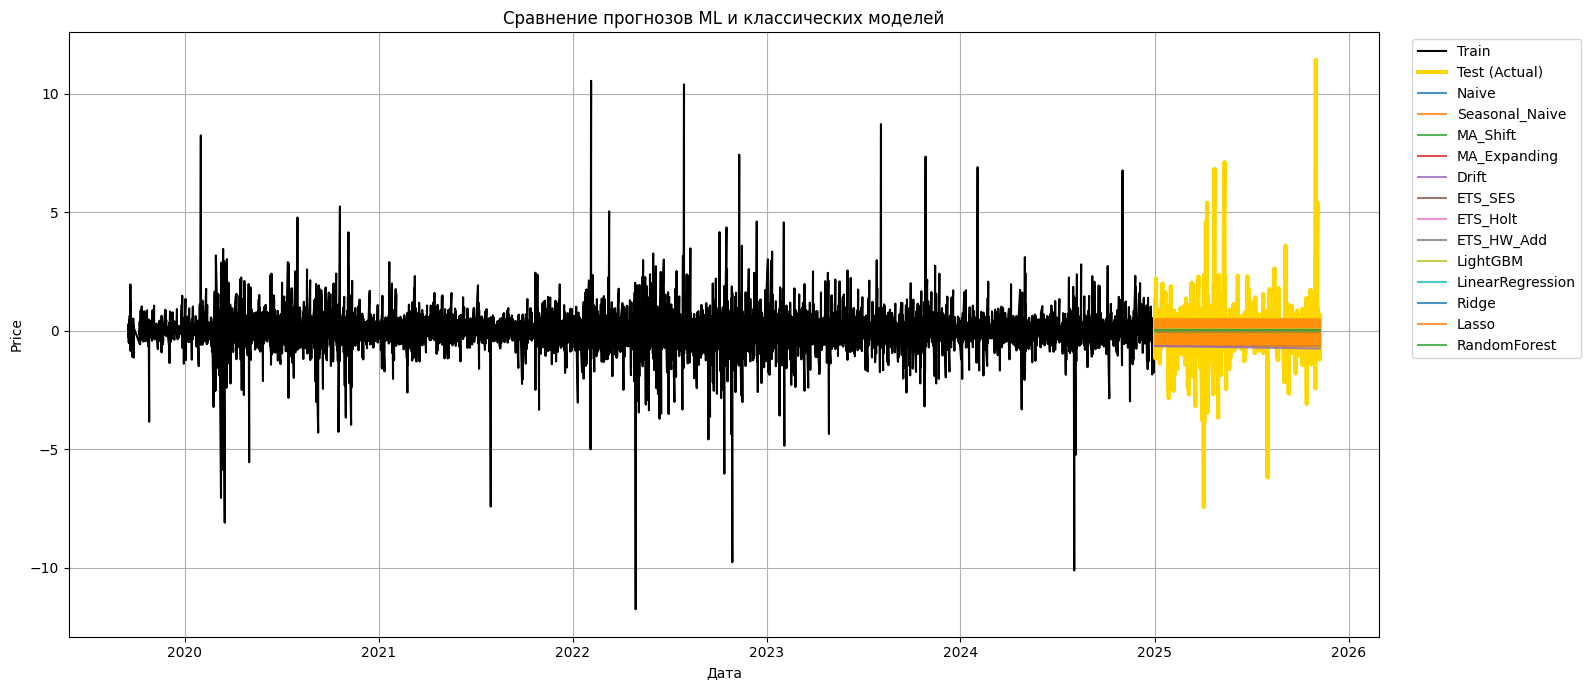

In [15]:
import warnings
import logging

warnings.filterwarnings("ignore")

logging.getLogger("lightgbm").setLevel(logging.ERROR)
logging.getLogger("torch").setLevel(logging.ERROR)
logging.getLogger("torchao").setLevel(logging.ERROR)
import matplotlib.pyplot as plt


def train_test_split_by_date(
    df,
    date_col="Datetime",
    split_date="2025-01-01",
    dropna=True
):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    if dropna:
        df = df.dropna()

    train = df[df[date_col] < split_date]
    test = df[df[date_col] >= split_date]
    return train, test


train, test = train_test_split_by_date(
    amzn,
    "Datetime",
    "2025-01-01"
)

y_train = train["Close_perc"]
horizon = len(test)

preds = pd.DataFrame({
    "Datetime": test["Datetime"].values,
    "Actual": test["Close_perc"].values
})

# 1) Наивная модель
preds["Naive"] = naive_forecast(
    y_train,
    horizon
)

# 2) Наивная сезонная модель
preds["Seasonal_Naive"] = seasonal_naive_forecast(
    y_train,
    horizon,
    season_length=26
)

# 3) MA_Shift
preds["MA_Shift"] = moving_average_forecast(
    y_train,
    horizon,
    window=120,
    mode="shift"
)

# 4) MA_Expanding
preds["MA_Expanding"] = moving_average_forecast(
    y_train,
    horizon,
    window=120,
    mode="expanding"
)

# 5) Drift
preds["Drift"] = drift_forecast(
    y_train,
    horizon
)

# 6) ETS модели
# SES
preds["ETS_SES"] = (
    exponential_smoothing_forecast(
        y_train,
        horizon,
        trend=None,
        seasonal=None
    )[0]
    .values
)

# Holt
preds["ETS_Holt"] = (
    exponential_smoothing_forecast(
        y_train,
        horizon,
        trend="add",
        seasonal=None
    )[0]
    .values
)

# Holt-Winters Additive
preds["ETS_HW_Add"] = (
    exponential_smoothing_forecast(
        y_train,
        horizon,
        trend="add",
        seasonal="add",
        seasonal_periods=26
    )[0]
    .values
)

# 7) LightGDM
lgb_preds, lgb_model = lgb_forecast(
    y_train,
    horizon,
    lags=(1, 2, 3, 7, 14, 28),
    rolling_windows=(7, 14, 28),
    n_estimators=200,
    learning_rate=0.05
)

preds["LightGBM"] = lgb_preds

# 8) Линейная регрессия
linear_preds, linear_model = linear_forecast(
    y_train,
    horizon,
    model_type="linear",
    lags=(1, 2, 3, 7, 14, 28),
    rolling_windows=(7, 14, 28)
)

preds["LinearRegression"] = linear_preds

# 9) Ридж регрессия
ridge_preds, ridge_model = linear_forecast(
    y_train,
    horizon,
    model_type="ridge",
    alpha=1.0,
    lags=(1, 2, 3, 7, 14, 28),
    rolling_windows=(7, 14, 28)
)

preds["Ridge"] = ridge_preds

# 10) Лассо
lasso_preds, lasso_model = linear_forecast(
    y_train,
    horizon,
    model_type="lasso",
    alpha=0.001,
    lags=(1, 2, 3, 7, 14, 28),
    rolling_windows=(7, 14, 28)
)

preds["Lasso"] = lasso_preds

# 11) рендом форест
rf_preds, rf_model = random_forest_forecast(
    y_train,
    horizon,
    lags=(1, 2, 3, 7, 14, 28),
    rolling_windows=(7, 14, 28),
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3
)

preds["RandomForest"] = rf_preds

# Визуализация
plt.figure(figsize=(16, 7))
plt.plot(train["Datetime"], y_train, label="Train", color="black")  # обучение
plt.plot(test["Datetime"], test["Close_perc"], label="Test (Actual)", color="gold", linewidth=3)  # Актуальные значения

# предсказание
for col in preds.columns:
    if col not in ("Datetime", "Actual"):
        plt.plot(preds["Datetime"], preds[col], label=col, alpha=0.8)

plt.title("Сравнение прогнозов ML и классических моделей")
plt.xlabel("Дата")
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()


naive_methods = preds.copy()

Epoch 1/10 | Loss: 0.225394
Epoch 2/10 | Loss: 0.187857
Epoch 3/10 | Loss: 0.188442
Epoch 4/10 | Loss: 0.188111
Epoch 5/10 | Loss: 0.188036
Epoch 6/10 | Loss: 0.187856
Epoch 7/10 | Loss: 0.187591
Epoch 8/10 | Loss: 0.187528
Epoch 9/10 | Loss: 0.187585
Epoch 10/10 | Loss: 0.187126
Epoch 1/10 | Loss: 1.002111
Epoch 2/10 | Loss: 1.001366
Epoch 3/10 | Loss: 1.001156
Epoch 4/10 | Loss: 1.001670
Epoch 5/10 | Loss: 1.000946
Epoch 6/10 | Loss: 1.000991
Epoch 7/10 | Loss: 1.003422
Epoch 8/10 | Loss: 1.000788
Epoch 9/10 | Loss: 1.001109
Epoch 10/10 | Loss: 1.001331
Epoch 1/10 | Loss: 1.002968
Epoch 2/10 | Loss: 1.001932
Epoch 3/10 | Loss: 1.002475
Epoch 4/10 | Loss: 1.001336
Epoch 5/10 | Loss: 1.001485
Epoch 6/10 | Loss: 1.002254
Epoch 7/10 | Loss: 1.001548
Epoch 8/10 | Loss: 1.003802
Epoch 9/10 | Loss: 1.001319
Epoch 10/10 | Loss: 1.001165


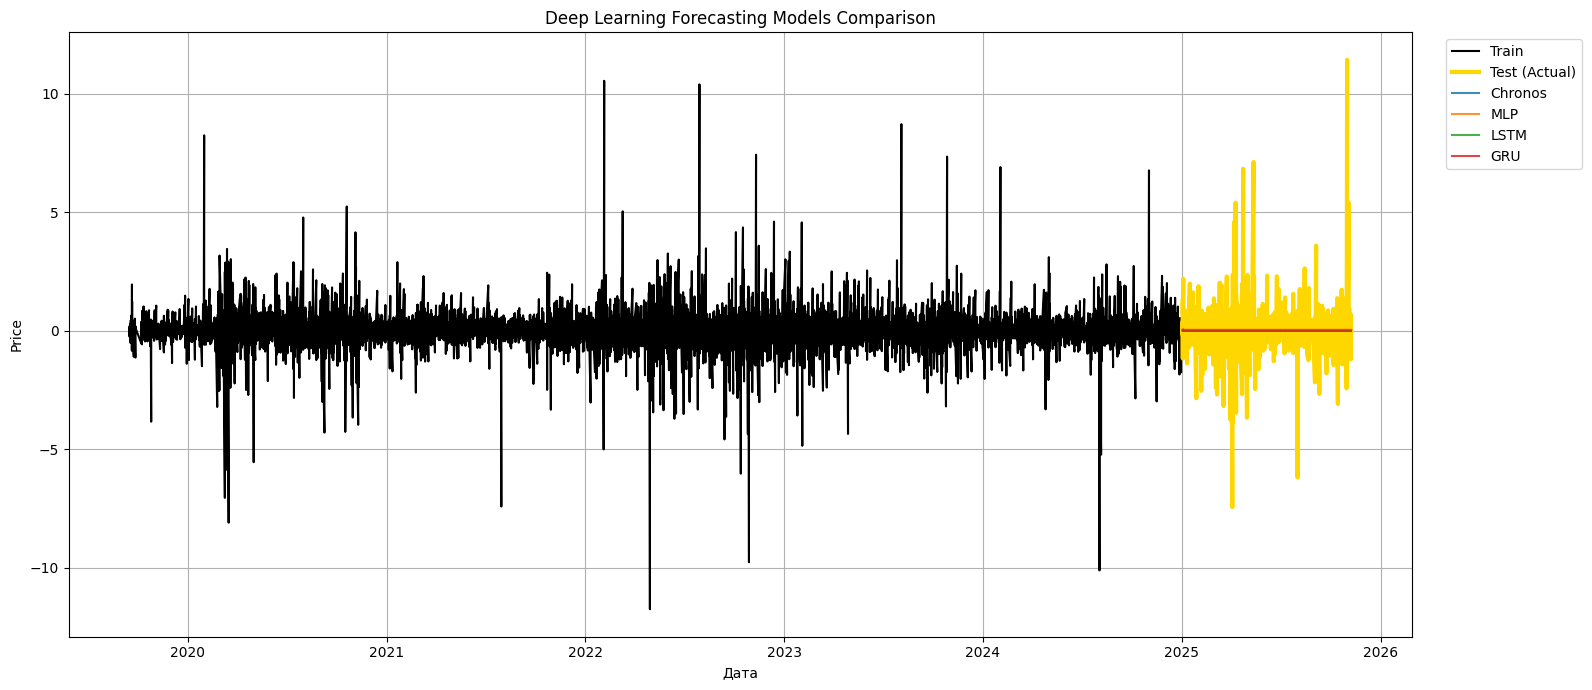

In [19]:
import warnings
import logging

warnings.filterwarnings("ignore")
logging.getLogger("torch").setLevel(logging.ERROR)
logging.getLogger("torchao").setLevel(logging.ERROR)
import matplotlib.pyplot as plt


train, test = train_test_split_by_date(amzn, "Datetime", "2025-01-01")
y_train = train["Close_perc"]
horizon = len(test)

dl_preds = pd.DataFrame({
    "Datetime": test["Datetime"].values,
    "Actual": test["Close_perc"].values
})

# 4) Предобученная chronos модель
chronos_preds, chronos_model = chronos_forecast(
    y_train,
    horizon,
    model_name="amazon/chronos-t5-mini",
    num_samples=5
)

dl_preds["Chronos"] = chronos_preds

# 1) MLP
mlp_preds, mlp_model = mlp_forecast_torch(
    y_train,
    horizon,

    hidden_layers=(256, 128, 64),
    activation="gelu",
    dropout_rate=0.3,
    use_batch_norm=True,
    optimizer_name="adamw",
    learning_rate=0.001,
    weight_decay=1e-4,
    use_scheduler=True,
    epochs=10,
    batch_size=64,
    early_stopping=True,
    patience=15,
    lags=(1, 2, 3, 7, 14, 28),
    rolling_windows=(7, 14, 28),
    verbose=True
)

dl_preds["MLP"] = mlp_preds

# 2) LSTM
lstm_preds, lstm_model = rnn_forecast_torch(
    y_train,
    horizon,

    rnn_type="lstm",
    sequence_length=56,
    hidden_size=32,
    num_layers=2,
    dropout=0.3,
    bidirectional=False,
    optimizer_name="adamw",
    learning_rate=0.001,
    weight_decay=1e-4,
    # scheduler
    use_scheduler=True,
    epochs=10,
    batch_size=64,
    early_stopping=True,
    patience=15,
    verbose=True
)

dl_preds["LSTM"] = lstm_preds

# 3) GRU
gru_preds, gru_model = rnn_forecast_torch(
    y_train,
    horizon,

    rnn_type="gru",
    sequence_length=56,
    hidden_size=32,
    num_layers=2,
    dropout=0.3,
    bidirectional=False,
    # оптимизатор
    optimizer_name="adamw",
    learning_rate=0.001,
    weight_decay=1e-4,
    # scheduler
    use_scheduler=True,

    epochs=10,
    batch_size=64,

    early_stopping=True,
    patience=15,
    verbose=True
)

dl_preds["GRU"] = gru_preds


# Визуализация
plt.figure(figsize=(16, 7))
plt.plot(train["Datetime"], y_train, label="Train", color="black") # трейн
plt.plot(test["Datetime"], test["Close_perc"], label="Test (Actual)", color="gold", linewidth=3) # актуальные значения

# предсказания
for col in dl_preds.columns:
    if col not in ("Datetime", "Actual"):
        plt.plot(dl_preds["Datetime"], dl_preds[col], label=col, alpha=0.85)

plt.title("Deep Learning Forecasting Models Comparison")
plt.xlabel("Дата")
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()


deep_learning_methods = dl_preds.copy()

In [20]:
all_models = (
    naive_methods
    .merge(
        deep_learning_methods.drop(columns=["Actual"]),
        on="Datetime",
        how="left"
    )
)


def evaluate_all_models(merged, target="Actual", baseline="Naive"):
    models = [col for col in merged.columns if col not in ("Datetime", target)]

    results = []

    for model in models:
        y_true = merged[target]
        y_pred = merged[model]
        y_base = merged[baseline]

        row = {
            "Model": model,

            # Асболютные ошибки
            "MAE": mae(y_true, y_pred),
            "MSE": mse(y_true, y_pred),
            "RMSE": rmse(y_true, y_pred),
            "MDAE": mdae(y_true, y_pred),
            "MDSE": mdse(y_true, y_pred),

            # Относительные ошибки
            "MAPE": mape(y_true, y_pred),
            "sMAPE": smape(y_true, y_pred),
            "MSPE": mspe(y_true, y_pred),
            "RMSPE": rmspe(y_true, y_pred),

            # Взвешанные
            "WAPE": wape(y_true, y_pred),

            # Нормализованные метрики
            "MASE": mase(y_true, y_pred, seasonality=1),
            "RMSSE": rmsse(y_true, y_pred, seasonality=1),

            # Относительно baseline (Naive)
            "RAE": rae(y_true, y_pred, y_base),
            "RSE": rse(y_true, y_pred, y_base),
            "RMAE": rmae(y_true, y_pred, y_base),
            "RRMSE": rrmse(y_true, y_pred, y_base),

            # Normalized
            "NRMSE_STD": nrmse_std(y_true, y_pred),
            "NMAE_RANGE": nmae_range(y_true, y_pred)
        }

        results.append(row)

    return pd.DataFrame(results)


metrics_df = evaluate_all_models(naive_methods[naive_methods['Actual'] != 0].copy(), target="Actual", baseline="Naive")
evaluation_df = all_models[all_models["Actual"] != 0].copy()

# Метрики
metrics_df = evaluate_all_models(
    evaluation_df,
    target="Actual",
    baseline="Naive"
)

metrics_df

,Model,MAE,MSE,RMSE,MDAE,MDSE,MAPE,sMAPE,MSPE,RMSPE,WAPE,MASE,RMSSE,RAE,RSE,RMAE,RRMSE,NRMSE_STD,NMAE_RANGE
0,Naive,0.687491,0.644571,0.802852,0.653779,0.427427,2298.266361,160.254388,122129.772331,349.470703,2.873891,1.941884,1.200877,1.004635,1.004032,1.004635,1.002014,1.706900,0.036421
1,Seasonal_Naive,0.335406,0.291578,0.539980,0.249592,0.062296,627.103130,149.608493,6259.373743,79.116204,1.402084,0.947386,0.807683,0.490131,0.454184,0.490131,0.673932,1.148022,0.017768
2,MA_Shift,0.241314,0.222476,0.471673,0.144940,0.021008,178.825236,159.386677,303.550754,17.422708,1.008757,0.681616,0.705512,0.352634,0.346545,0.352634,0.588680,1.002799,0.012784
3,MA_Expanding,0.240131,0.221803,0.470960,0.144193,0.020792,147.532805,167.722556,126.955903,11.267471,1.003812,0.678274,0.704445,0.350906,0.345497,0.350906,0.587790,1.001283,0.012721
4,Drift,0.738139,0.717809,0.847236,0.710645,0.505016,2537.993521,161.988770,155813.822130,394.732596,3.085611,2.084943,1.267265,1.078647,1.118112,1.078647,1.057408,1.801263,0.039104
5,ETS_SES,0.239219,0.221236,0.470357,0.144505,0.020882,105.692556,190.010949,4.507350,2.123052,0.999997,0.675696,0.703543,0.349572,0.344613,0.349572,0.587038,1.000000,0.012673
6,ETS_Holt,0.239220,0.221236,0.470357,0.144614,0.020913,106.058815,189.623303,4.908776,2.215576,1.000000,0.675699,0.703543,0.349573,0.344613,0.349573,0.587038,1.000001,0.012673
7,ETS_HW_Add,0.239363,0.221332,0.470459,0.144472,0.020872,112.904053,182.504695,13.442811,3.666444,1.000601,0.676105,0.703696,0.349783,0.344763,0.349783,0.587166,1.000219,0.012681
8,LightGBM,0.242212,0.222737,0.471951,0.148361,0.022011,196.741346,157.509855,443.873278,21.068300,1.012507,0.684150,0.705927,0.353945,0.346952,0.353945,0.589027,1.003389,0.012831
9,LinearRegression,0.239217,0.221228,0.470349,0.144266,0.020813,104.912382,190.869211,3.746754,1.935653,0.999990,0.675692,0.703531,0.349570,0.344601,0.349570,0.587027,0.999983,0.012673




В рамках 6 чекпоинта удалось добавить следующие ML и DL модели с возможностью выбора гиперпараметров:


*   Авторегрессионная модель. Для линейных моделей была реализована единая функция linear_forecast() с поддержкой выбора типа модели (линейная регрессия, ридж-регуляризация, лассо-регуляризация), с настройкой регуляризации, стандартизацией признаков, формированием лаговых и сколльзящих признаков, и выбором фичей
*   RandomForestRegressor с возможностью выбора основных его гиперпараметров (по аналогии с LightGDM)
*   Многослойный перцептрон (MLP) с возомжностью выбора архитектуры скрытых слоёв, дропаута, батч-нормализации, функции ошибки, оптимизатора, ранней остановки и тд.
*   Рекурентные модели (LSTM и GRU)
*   Предобученная модель от Amazon Chronos которую можно использовать напрямую в нашем сервисе

По результатам эксперимента сложные DL модели не дали значимого прироста в качестве (скорее всего это связано с большим тестовым горизонтом, рекомендуется прогнозировать не более чем на 50 точек вперед). Наилучший RMSE показала GRU модель

